# 1.0 Project Overview

### 1.1 Real Life Problem

Traffic accidents are a common and persistent public safety issue worldwide, occurring daily in both urban and rural settings. According to the World Health Organization, road traffic accidents result in over a million fatalities each year, with many people experiencing both health and financial losses. In major cities, these accidents can be contributed by either:

* Human related factors such as distracted driving, speeding or impaired driving.

* Vehicle related factors such as vehicle defect and vehicle model.

* Environmental related factors such as poor weather, low visibility and road surface issues such as poorly maintained roads.

Understanding these factors is essential to reducing traffic accidents and developing effective safety measures.


### 1.2 Invested stakeholders

Several groups might benefit significantly from the traffic accidents data and insights drawn from understanding the primary contributory causes. These might include:

1. Government and city authorities - who might use this to identify high risk areas and improve on road infrastructure while implementing policies aimed at reducing accidents.

2. Public safety organizations - such as the Vehicle Safety Board who might use the data to aid in designing regulation and safety campaigns and enforcement strategies based on observed trends.

3. General public and drivers - who might benefit from better awareness of risk factors.

4. Vehicle manufacturers - who might leverage on insights to improve car safety features such as weather detection systems.

# 2.0 Business Understanding

### 2.1 Business Problem
Large cities such as the City of Chicago experience frequent traffic accidents often. To address this challenge, there is need for a predictive model that can identify **primary contributory cause of car accidents** using key influencing factors including:

1. Human Factors such as sex and age.

2. Vehicle Factors such as vehicle make.

3. Environmental Factors such as weather patterns.

4. Temporal Factors such as Date and Time of the Accidents.

5. Road Design Characteristics such as road defects and road surface conditions.

Such a model would support data driven decision making aimed at reducing accident rates and improving overall road safety.

### 2.2 Business Questions
The project seeks to answer the following business questions:

1. What are the most common primary contributory causes of traffic accidents?

2. How do human characteristics contribute to accident occurrence?

3. How do vehicle characteristics contribute to accident occurrence?

4. How do environmental conditions such as weather influence accident occurrence?

5. Are there specific times when accidents are more likely to occur?

6. How does road design impact the likelihood of accidents?

7. Can we accurately predict the primary cause of an accident given the human, vehicle, environmental, temporal and road design characteristics?

### 2.3 Business Objectives
The main objectives of this project are to:

1. Develop a predictive model that can classify the primary contributory cause of traffic accidents.

2. Identify key factors (Human, Vehicle, Environmental, Temporal) that significantly influence accident occurrence.


# 3.0 Data Understanding

### 3.1 Data Description and Sources

* This project utilized 3 datasets that contain information on the accident occurence, characteristics of people involved as well as the vehicle characteristics. These are:

1. City of Chicago Accident Dataset - sourced from https://data.cityofchicago.org/Transportation/Traffic-Crashes-Crashes/85ca-t3if.
This dataset has 1.04 million rows and 48 columns. Each row is a traffic crash with the row identifier as the CRASH_RECORD_ID.
2. Vehicle Accident Dataset sourced from https://data.cityofchicago.org/Transportation/Traffic-Crashes-Vehicles/68nd-jvt3.  It has 2.28 million rows and 29 columns. Each row is a person with the row identifier as the PERSON_ID. The dataset also has CRASH_RECORD_ID.
3. Driver/Passenger Accident Dataset sourced from https://data.cityofchicago.org/Transportation/Traffic-Crashes-People/u6pd-qa9d. It has 2.12 million rows with 71 columns. Each row is a vehicle with the row identifier as the CRASH_UNIT_ID. This dataset however also has a CRASH_RECORD_ID.

**Note**: Our goal is to merge the three datasets using the common CRASH_RECORD_ID, creating a unified dataset that combines all relevant features for our analysis.

From the merger, we aim to use the following columns from the following datasets:

1. City of Chicago Dataset: 

* Weather condition - Weather condition at time of crash.
* Lightning condition - Light condition at time of crash.
* Road defects - Road defects, as determined by reporting officer.
* Crash type - A general severity classification for the crash. Can be either Injury and/or Tow Due to Crash or No Injury / Drive Away.
* Primary Contributory Cause - The factor which was most significant in causing the crash.
* Crash hour - The hour of the day component of CRASH_DATE.
* Crash day - The day of the week component of CRASH_DATE.
* Crash month - The month component of CRASH_DATE.

2. Vehicle Dataset:

* Number of passengers - Number of passengers in the vehicle. The driver is not included.
* Make - The make (brand) of the vehicle.
* Vehicle Use - The normal use of the vehicle.
* Vehicle Defect - Defect the vehicle had.
* Exceeds speed limit - Whether vehicle exceeded speed limit.

3. Passenger Dataset:

* Person type - Type of roadway user involved in crash.
* Sex - Gender of person involved in crash.
* Age - Age of person involved in crash.
* Driver Vision - What, if any, objects obscured the driver’s vision at time of crash.
* Physical Condition - Driver’s apparent physical condition at time of crash.
* Driver Action - Driver action that contributed to the crash.
* Pedpedal Action - Action of pedestrian or cyclist at the time of crash.



### 3.2 Target Variable
* Our target variable is: Primary contributory cause which is a multiclass classification problem.
There are 40 values of the aforementioned target variable and we aim to predict the most common primary contributory causes based on our feature variables.

### 3.3 Feature Variables
* All the other aforementioned variables other than primary contributory cause will act as our feature variables. They will be specifically selected following a merger of the 3 Datasets.

### 3.4 Challenge with large samples of rows
Following the merger, we expect 2 challenges:

1. Since a single crash may involve more than just the driver, each CRASH_RECORD_ID could correspond to multiple people. To simplify the analysis, we will focus on drivers, examining each crash event from the perspective of the drivers involved.
2. A single crash can involve multiple vehicles, so if a crash involves two cars with one person in each, it would result in at least two rows—one for each individual involved in the same crash.
3. The dataset contains millions of rows, which may exceed available computing resources. To manage this, we will limit our analysis to approximately 500,000 randomly selected samples after data cleaning, which will also help reduce the dataset size naturally.

# 4.0 Data Preparation and Cleaning

### 4.1 Data Preparation

* In this section we will load the data, select the columns we want to work with and limit it only to drivers

In [1]:
# We will start by importing the necessary libraries for data cleaning and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Loading the 3 Datasets and saving them under different variable names. Starting with accidents_data and checking our data.

accidents_log = pd.read_csv("accidents.csv", low_memory = False) # Low memory helps pandas to read the entire file at once when determining column types
accidents_log.head()

,CRASH_RECORD_ID,CRASH_DATE_EST_I,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,...,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,LOCATION
0,c4658ba1425251e03a299caf165125eba8af03229e2238...,NaN,03/24/2026 11:10:00 PM,20,STOP SIGN/FLASHER,FUNCTIONING PROPERLY,CLEAR,DARKNESS,FIXED OBJECT,OTHER,...,NaN,NaN,NaN,NaN,23,3,3,41.876214,-87.749114,POINT (-87.749114396596 41.876214475743)
1,169bb4297ce8f9de0b432baae8e5c61fccff5f877be0e0...,NaN,03/24/2026 10:45:00 PM,30,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,ONE-WAY,...,0.0,0.0,2.0,0.0,22,3,3,41.774542,-87.604726,POINT (-87.604726471916 41.774541988748)
2,ebc0228a98d221f831a0f232dc0c310c2d15d47e1a976b...,NaN,03/24/2026 10:25:00 PM,10,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",REAR TO SIDE,PARKING LOT,...,0.0,0.0,2.0,0.0,22,3,3,41.696314,-87.596632,POINT (-87.596632243933 41.696313683973)
3,4ca882872708f63d8e3f3d30f0b4cd885132273e9b7708...,NaN,03/24/2026 10:18:00 PM,40,NO CONTROLS,NO CONTROLS,CLEAR,DARKNESS,PARKED MOTOR VEHICLE,NOT DIVIDED,...,0.0,0.0,3.0,0.0,22,3,3,41.802117,-87.622206,POINT (-87.622206182567 41.802117124614)
4,f8c941528e1bdd2a112d6c25ea37e289e92e724498b198...,NaN,03/24/2026 10:09:00 PM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,"DARKNESS, LIGHTED ROAD",ANGLE,FOUR WAY,...,1.0,0.0,1.0,0.0,22,3,3,41.765109,-87.644557,POINT (-87.644556951763 41.765109431911)


In [3]:
# Loading the passenger data and checking our data
passenger_log = pd.read_csv("passenger.csv", low_memory = False)
passenger_log.head()

,PERSON_ID,PERSON_TYPE,CRASH_RECORD_ID,VEHICLE_ID,CRASH_DATE,SEAT_NO,CITY,STATE,ZIPCODE,SEX,...,EMS_RUN_NO,DRIVER_ACTION,DRIVER_VISION,PHYSICAL_CONDITION,PEDPEDAL_ACTION,PEDPEDAL_VISIBILITY,PEDPEDAL_LOCATION,BAC_RESULT,BAC_RESULT VALUE,CELL_PHONE_USE
0,O2271292,DRIVER,169bb4297ce8f9de0b432baae8e5c61fccff5f877be0e0...,2165998.0,03/24/2026 10:45:00 PM,NaN,DAVENPORT,IA,52804,F,...,NaN,OTHER,NOT OBSCURED,NORMAL,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN
1,P499550,PASSENGER,169bb4297ce8f9de0b432baae8e5c61fccff5f877be0e0...,2165998.0,03/24/2026 10:45:00 PM,3.0,ROCK ISLND,IL,61201,M,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,O2271266,DRIVER,ebc0228a98d221f831a0f232dc0c310c2d15d47e1a976b...,2165976.0,03/24/2026 10:25:00 PM,NaN,CHICAGO,IL,60617,M,...,NaN,IMPROPER BACKING,NOT OBSCURED,NORMAL,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN
3,O2271267,DRIVER,ebc0228a98d221f831a0f232dc0c310c2d15d47e1a976b...,2165981.0,03/24/2026 10:25:00 PM,NaN,CHICAGO,IL,60628,M,...,NaN,NONE,NOT OBSCURED,NORMAL,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN
4,O2271268,DRIVER,4ca882872708f63d8e3f3d30f0b4cd885132273e9b7708...,2165979.0,03/24/2026 10:18:00 PM,NaN,CHICAGO,IL,60827,F,...,NaN,UNKNOWN,NOT OBSCURED,NORMAL,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN


In [4]:
# Loading the vehicle data and checking our data
vehicle_log = pd.read_csv("vehicles.csv", low_memory = False)
vehicle_log.head()

,CRASH_UNIT_ID,CRASH_RECORD_ID,CRASH_DATE,UNIT_NO,UNIT_TYPE,NUM_PASSENGERS,VEHICLE_ID,CMRC_VEH_I,MAKE,MODEL,...,TRAILER1_LENGTH,TRAILER2_LENGTH,TOTAL_VEHICLE_LENGTH,AXLE_CNT,VEHICLE_CONFIG,CARGO_BODY_TYPE,LOAD_TYPE,HAZMAT_OUT_OF_SERVICE_I,MCS_OUT_OF_SERVICE_I,HAZMAT_CLASS
0,2271287,c4658ba1425251e03a299caf165125eba8af03229e2238...,03/24/2026 11:10:00 PM,1,DRIVERLESS,NaN,2165992.0,NaN,FORD,FUSION,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2271292,169bb4297ce8f9de0b432baae8e5c61fccff5f877be0e0...,03/24/2026 10:45:00 PM,1,DRIVER,1.0,2165998.0,NaN,GENERAL MOTORS CORPORATION (GMC),ACADIA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2271293,169bb4297ce8f9de0b432baae8e5c61fccff5f877be0e0...,03/24/2026 10:45:00 PM,2,PARKED,NaN,2166003.0,NaN,CHRYSLER,OTHER (EXPLAIN IN NARRATIVE),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2271266,ebc0228a98d221f831a0f232dc0c310c2d15d47e1a976b...,03/24/2026 10:25:00 PM,1,DRIVER,NaN,2165976.0,NaN,CHEVROLET,IMPALA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2271267,ebc0228a98d221f831a0f232dc0c310c2d15d47e1a976b...,03/24/2026 10:25:00 PM,2,DRIVER,NaN,2165981.0,NaN,LEXUS,300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Checking the different columns in each dataset
accidents_log.columns, passenger_log.columns, vehicle_log.columns

(Index(['CRASH_RECORD_ID', 'CRASH_DATE_EST_I', 'CRASH_DATE',
        'POSTED_SPEED_LIMIT', 'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION',
        'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE',
        'TRAFFICWAY_TYPE', 'LANE_CNT', 'ALIGNMENT', 'ROADWAY_SURFACE_COND',
        'ROAD_DEFECT', 'REPORT_TYPE', 'CRASH_TYPE', 'INTERSECTION_RELATED_I',
        'NOT_RIGHT_OF_WAY_I', 'HIT_AND_RUN_I', 'DAMAGE', 'DATE_POLICE_NOTIFIED',
        'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE', 'STREET_NO',
        'STREET_DIRECTION', 'STREET_NAME', 'BEAT_OF_OCCURRENCE',
        'PHOTOS_TAKEN_I', 'STATEMENTS_TAKEN_I', 'DOORING_I', 'WORK_ZONE_I',
        'WORK_ZONE_TYPE', 'WORKERS_PRESENT_I', 'NUM_UNITS',
        'MOST_SEVERE_INJURY', 'INJURIES_TOTAL', 'INJURIES_FATAL',
        'INJURIES_INCAPACITATING', 'INJURIES_NON_INCAPACITATING',
        'INJURIES_REPORTED_NOT_EVIDENT', 'INJURIES_NO_INDICATION',
        'INJURIES_UNKNOWN', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH',
     

In [6]:
# Select ONLY the specific columns we outlined in Section 3.1
crash_cols = ['CRASH_RECORD_ID', 'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'ROAD_DEFECT', 
              'CRASH_TYPE', 'PRIM_CONTRIBUTORY_CAUSE', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH']

vehicle_cols = ['CRASH_RECORD_ID', 'OCCUPANT_CNT', 'MAKE', 
                'VEHICLE_USE', 'VEHICLE_DEFECT', 'EXCEED_SPEED_LIMIT_I']

passenger_cols = ['CRASH_RECORD_ID', 'PERSON_TYPE', 'SEX', 'AGE', 'DRIVER_VISION', 
                  'PHYSICAL_CONDITION', 'DRIVER_ACTION', 'PEDPEDAL_ACTION']

# Subset the dataframes to drop the 100+ columns we don't need
accidents_sub = accidents_log[crash_cols]
vehicle_sub = vehicle_log[vehicle_cols]
passenger_sub = passenger_log[passenger_cols]

In [7]:
# Going forward, we want to focus our dataset purely on factors that affect drivers
# Of the 3 datasets, we can specify drivers only in the passenger_log data as this has the persons column where we can specify the person involved in the crash
# The other datasets do not have 'persons' column to specify the person involved in the crash.
# However, after specifying the drivers and merging the datasets, we expect to have one dataset where the data concerns only drivers

drivers_only = passenger_sub[passenger_sub['PERSON_TYPE'] == 'DRIVER'].copy()

In [8]:
# We now want to merge the 3 datasets; accidents, passenger, and vehicles csv datasets
# From the above, we notice that the 3 datasets share the 'CRASH_RECORD_ID' column. We will therefore use pandas.merge to merge them based on this.
# We will first merge accidents_sub with vehicles_unique

merged_accidents_vehicles = pd.merge(
    accidents_sub,
    vehicle_sub,
    how = 'left',
    on = 'CRASH_RECORD_ID'
)

# we will then merge the combined merged_accidents_vehicles with drivers_unique to have 1 full dataset called merged_df
merged_df = pd.merge(
    drivers_only,
    merged_accidents_vehicles,
    how = 'left',
    on = 'CRASH_RECORD_ID'
)

# Check the merged_df
merged_df.head()

,CRASH_RECORD_ID,PERSON_TYPE,SEX,AGE,DRIVER_VISION,PHYSICAL_CONDITION,DRIVER_ACTION,PEDPEDAL_ACTION,WEATHER_CONDITION,LIGHTING_CONDITION,...,CRASH_TYPE,PRIM_CONTRIBUTORY_CAUSE,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,OCCUPANT_CNT,MAKE,VEHICLE_USE,VEHICLE_DEFECT,EXCEED_SPEED_LIMIT_I
0,169bb4297ce8f9de0b432baae8e5c61fccff5f877be0e0...,DRIVER,F,32.0,NOT OBSCURED,NORMAL,OTHER,NaN,CLEAR,"DARKNESS, LIGHTED ROAD",...,NO INJURY / DRIVE AWAY,UNABLE TO DETERMINE,22,3,3,2.0,GENERAL MOTORS CORPORATION (GMC),PERSONAL,UNKNOWN,NaN
1,169bb4297ce8f9de0b432baae8e5c61fccff5f877be0e0...,DRIVER,F,32.0,NOT OBSCURED,NORMAL,OTHER,NaN,CLEAR,"DARKNESS, LIGHTED ROAD",...,NO INJURY / DRIVE AWAY,UNABLE TO DETERMINE,22,3,3,0.0,CHRYSLER,PERSONAL,UNKNOWN,NaN
2,ebc0228a98d221f831a0f232dc0c310c2d15d47e1a976b...,DRIVER,M,40.0,NOT OBSCURED,NORMAL,IMPROPER BACKING,NaN,CLEAR,"DARKNESS, LIGHTED ROAD",...,NO INJURY / DRIVE AWAY,IMPROPER BACKING,22,3,3,1.0,CHEVROLET,PERSONAL,NONE,NaN
3,ebc0228a98d221f831a0f232dc0c310c2d15d47e1a976b...,DRIVER,M,40.0,NOT OBSCURED,NORMAL,IMPROPER BACKING,NaN,CLEAR,"DARKNESS, LIGHTED ROAD",...,NO INJURY / DRIVE AWAY,IMPROPER BACKING,22,3,3,1.0,LEXUS,PERSONAL,NONE,NaN
4,ebc0228a98d221f831a0f232dc0c310c2d15d47e1a976b...,DRIVER,M,50.0,NOT OBSCURED,NORMAL,NONE,NaN,CLEAR,"DARKNESS, LIGHTED ROAD",...,NO INJURY / DRIVE AWAY,IMPROPER BACKING,22,3,3,1.0,CHEVROLET,PERSONAL,NONE,NaN


In [9]:
# Checking the length of the merged datasets
len(merged_df) # we are dealing with 1,192,524  entries

1192524

In [10]:
# checking the number of columns
len(merged_df.columns) # we have a total of 21 columns

21

In [11]:
merged_df.head()

,CRASH_RECORD_ID,PERSON_TYPE,SEX,AGE,DRIVER_VISION,PHYSICAL_CONDITION,DRIVER_ACTION,PEDPEDAL_ACTION,WEATHER_CONDITION,LIGHTING_CONDITION,...,CRASH_TYPE,PRIM_CONTRIBUTORY_CAUSE,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,OCCUPANT_CNT,MAKE,VEHICLE_USE,VEHICLE_DEFECT,EXCEED_SPEED_LIMIT_I
0,169bb4297ce8f9de0b432baae8e5c61fccff5f877be0e0...,DRIVER,F,32.0,NOT OBSCURED,NORMAL,OTHER,NaN,CLEAR,"DARKNESS, LIGHTED ROAD",...,NO INJURY / DRIVE AWAY,UNABLE TO DETERMINE,22,3,3,2.0,GENERAL MOTORS CORPORATION (GMC),PERSONAL,UNKNOWN,NaN
1,169bb4297ce8f9de0b432baae8e5c61fccff5f877be0e0...,DRIVER,F,32.0,NOT OBSCURED,NORMAL,OTHER,NaN,CLEAR,"DARKNESS, LIGHTED ROAD",...,NO INJURY / DRIVE AWAY,UNABLE TO DETERMINE,22,3,3,0.0,CHRYSLER,PERSONAL,UNKNOWN,NaN
2,ebc0228a98d221f831a0f232dc0c310c2d15d47e1a976b...,DRIVER,M,40.0,NOT OBSCURED,NORMAL,IMPROPER BACKING,NaN,CLEAR,"DARKNESS, LIGHTED ROAD",...,NO INJURY / DRIVE AWAY,IMPROPER BACKING,22,3,3,1.0,CHEVROLET,PERSONAL,NONE,NaN
3,ebc0228a98d221f831a0f232dc0c310c2d15d47e1a976b...,DRIVER,M,40.0,NOT OBSCURED,NORMAL,IMPROPER BACKING,NaN,CLEAR,"DARKNESS, LIGHTED ROAD",...,NO INJURY / DRIVE AWAY,IMPROPER BACKING,22,3,3,1.0,LEXUS,PERSONAL,NONE,NaN
4,ebc0228a98d221f831a0f232dc0c310c2d15d47e1a976b...,DRIVER,M,50.0,NOT OBSCURED,NORMAL,NONE,NaN,CLEAR,"DARKNESS, LIGHTED ROAD",...,NO INJURY / DRIVE AWAY,IMPROPER BACKING,22,3,3,1.0,CHEVROLET,PERSONAL,NONE,NaN


In [12]:
 #Save the clean dataset into our folder
merged_df.to_csv('chicago_crashes_cleaned.csv', index=False)

### 4.2 Data Cleaning

* In this section we will explore the datatypes, look for missing values and fill them.
* We will not drop duplicates because we are assuming that each CRASH_RECORD_ID is shared between 2 drivers; the driver who caused the accident and the one affected. We will therefore treat each driver row as an independent accident.

In [13]:
# Exploring the datatypes

merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1192524 entries, 0 to 1192523
Data columns (total 21 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   CRASH_RECORD_ID          1192524 non-null  object 
 1   PERSON_TYPE              1192524 non-null  object 
 2   SEX                      1192524 non-null  object 
 3   AGE                      875804 non-null   float64
 4   DRIVER_VISION            1192524 non-null  object 
 5   PHYSICAL_CONDITION       1192524 non-null  object 
 6   DRIVER_ACTION            1192524 non-null  object 
 7   PEDPEDAL_ACTION          0 non-null        object 
 8   WEATHER_CONDITION        1192524 non-null  object 
 9   LIGHTING_CONDITION       1192524 non-null  object 
 10  ROAD_DEFECT              1192524 non-null  object 
 11  CRASH_TYPE               1192524 non-null  object 
 12  PRIM_CONTRIBUTORY_CAUSE  1192524 non-null  object 
 13  CRASH_HOUR               1192524 non-null 

Of the 21 variables, 5 are numerical: CRASH_HOUR, CRASH_DAY_OF_WEEK, CRASH_MONTH, OCCUPANT_COUNT, AGE.

The remaining variables are all of the string datatype.

In [14]:
# Dropping the column 'CRASH_RECORD_ID' as it is not needed for our analysis
merged_df.drop(columns=['CRASH_RECORD_ID'], inplace=True)


In [15]:
# we will now check for missing data
merged_df.isna().sum()

PERSON_TYPE                      0
SEX                              0
AGE                         316720
DRIVER_VISION                    0
PHYSICAL_CONDITION               0
DRIVER_ACTION                    0
PEDPEDAL_ACTION            1192524
WEATHER_CONDITION                0
LIGHTING_CONDITION               0
ROAD_DEFECT                      0
CRASH_TYPE                       0
PRIM_CONTRIBUTORY_CAUSE          0
CRASH_HOUR                       0
CRASH_DAY_OF_WEEK                0
CRASH_MONTH                      0
OCCUPANT_CNT                 18281
MAKE                         18281
VEHICLE_USE                  18281
VEHICLE_DEFECT               18281
EXCEED_SPEED_LIMIT_I       1192516
dtype: int64

The following variables had missing values: 
* AGE                         316720
* PEDPEDAL_ACTION            1192524
* OCCUPANT_CNT                 18281
* MAKE                         18281
* VEHICLE_USE                  18281
* VEHICLE_DEFECT               18281
* EXCEED_SPEED_LIMIT_I       1192516

In [16]:
# Given that we had 1,192,524 entries and the column with the highest missing values (PEDPEDAL_ACTION) had 1,192,524  missing entries, and EXCEED_SPEED_LIMIT_I had 1,192,516 missing entries, we will drop both columns.

merged_df.drop(columns=['EXCEED_SPEED_LIMIT_I','PEDPEDAL_ACTION'],inplace=True)

# Confirming that we have deopped the 2 columns
merged_df.columns   # we have dropped the 2 columns

Index(['PERSON_TYPE', 'SEX', 'AGE', 'DRIVER_VISION', 'PHYSICAL_CONDITION',
       'DRIVER_ACTION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION',
       'ROAD_DEFECT', 'CRASH_TYPE', 'PRIM_CONTRIBUTORY_CAUSE', 'CRASH_HOUR',
       'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'OCCUPANT_CNT', 'MAKE',
       'VEHICLE_USE', 'VEHICLE_DEFECT'],
      dtype='object')

In [17]:
# Of the remaining variables, the one with the highest missing values is age with 316,720 missing values out of 1,192,524 total entries.
# This constitiutes 26.6% of the total data. Filling in these values with either mean or median might lead to erroneous data. 
# We therefore opt to drop these missing values completely.

merged_df.dropna(inplace=True)

#confirming that we have dropped all missing values
merged_df.isna().sum()  #We have dropped all missing values

PERSON_TYPE                0
SEX                        0
AGE                        0
DRIVER_VISION              0
PHYSICAL_CONDITION         0
DRIVER_ACTION              0
WEATHER_CONDITION          0
LIGHTING_CONDITION         0
ROAD_DEFECT                0
CRASH_TYPE                 0
PRIM_CONTRIBUTORY_CAUSE    0
CRASH_HOUR                 0
CRASH_DAY_OF_WEEK          0
CRASH_MONTH                0
OCCUPANT_CNT               0
MAKE                       0
VEHICLE_USE                0
VEHICLE_DEFECT             0
dtype: int64

In [18]:
# A quick scan of all the variables noted inconsistencies with the age variable
pd.cut(merged_df['AGE'], bins=10).value_counts() # Our age variable has a lot of inconsistencies with some entries having negative age values.

# We will now exclude the entries with negative age values and then recheck the age variable
merged_df = merged_df[merged_df['AGE'] >= 1]


#Confirming that all negative age values have been dropped
pd.cut(merged_df['AGE'], bins=10).value_counts() # We have successfully dropped all negative age values and we can now see that the age variable has more consistent values. We can now proceed with our analysis.


AGE
(22.8, 33.7]     259792
(33.7, 44.6]     203605
(44.6, 55.5]     147259
(55.5, 66.4]     104247
(11.9, 22.8]      82895
(66.4, 77.3]      47329
(77.3, 88.2]      11599
(88.2, 99.1]        977
(0.891, 11.9]       814
(99.1, 110.0]        33
Name: count, dtype: int64

In [19]:
# Confirming the new number of tatal entries
len(merged_df)      #We are now working with 858,550 total complete entries.

858550

In [20]:
 #Save the final cleaned dataset into our folder
merged_df.to_csv('chicago_crashes_final_dataset_cleaned.csv', index=False)

# 5.0 Exploratory Data Analysis

### 5.1 The most common primary contributory causes of traffic accidents


In [21]:
merged_df['PRIM_CONTRIBUTORY_CAUSE'].value_counts().head(10)

PRIM_CONTRIBUTORY_CAUSE
UNABLE TO DETERMINE                       291352
FAILING TO YIELD RIGHT-OF-WAY             124226
FOLLOWING TOO CLOSELY                      98174
IMPROPER OVERTAKING/PASSING                50970
FAILING TO REDUCE SPEED TO AVOID CRASH     42900
IMPROPER TURNING/NO SIGNAL                 36264
NOT APPLICABLE                             33996
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE        30640
IMPROPER LANE USAGE                        30163
DISREGARDING TRAFFIC SIGNALS               23579
Name: count, dtype: int64

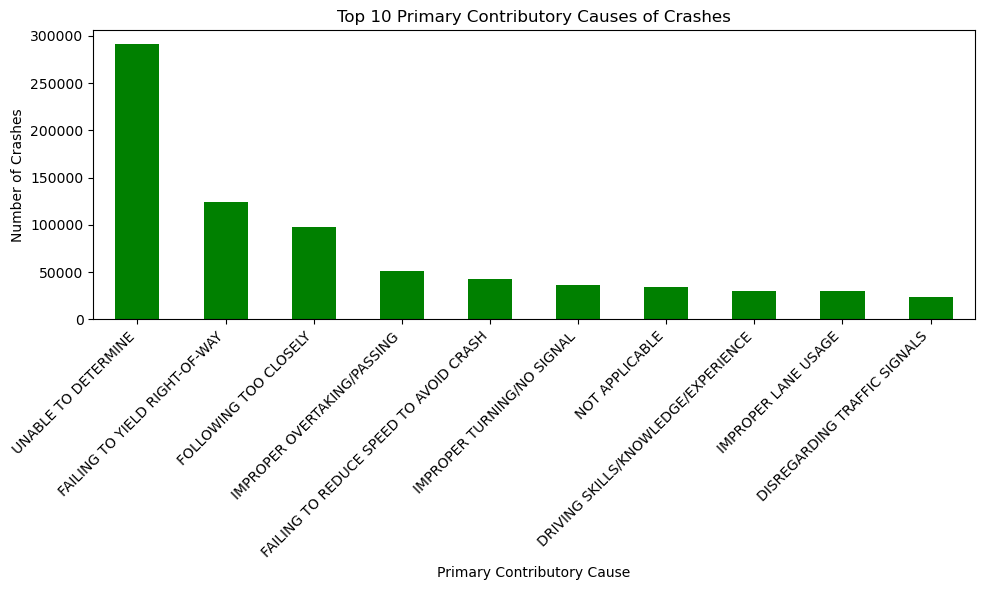

In [22]:
#illustrating the top 10 primary contributory causes of crashes in a bar chart
fig, ax =plt.subplots(figsize=(10, 6))
cause_counts = merged_df['PRIM_CONTRIBUTORY_CAUSE'].value_counts().head(10)
cause_counts.plot(kind='bar', ax=ax, color='green')
ax.set_xlabel('Primary Contributory Cause')
ax.set_ylabel('Number of Crashes')
ax.set_title('Top 10 Primary Contributory Causes of Crashes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.2 - 5.6 How do characteristics contribute to accident occurence?

In this part of the EDA we will summarize the impact of: 
* Human characteristics
* Environmental conditions
* Vehicle characteristics
* Temporal factors
* Road design factors

In [23]:
# Rechecking the data columns
merged_df.columns

Index(['PERSON_TYPE', 'SEX', 'AGE', 'DRIVER_VISION', 'PHYSICAL_CONDITION',
       'DRIVER_ACTION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION',
       'ROAD_DEFECT', 'CRASH_TYPE', 'PRIM_CONTRIBUTORY_CAUSE', 'CRASH_HOUR',
       'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'OCCUPANT_CNT', 'MAKE',
       'VEHICLE_USE', 'VEHICLE_DEFECT'],
      dtype='object')

PERSON_TYPE is categorical with value counts:
PERSON_TYPE
DRIVER    858550
Name: count, dtype: int64



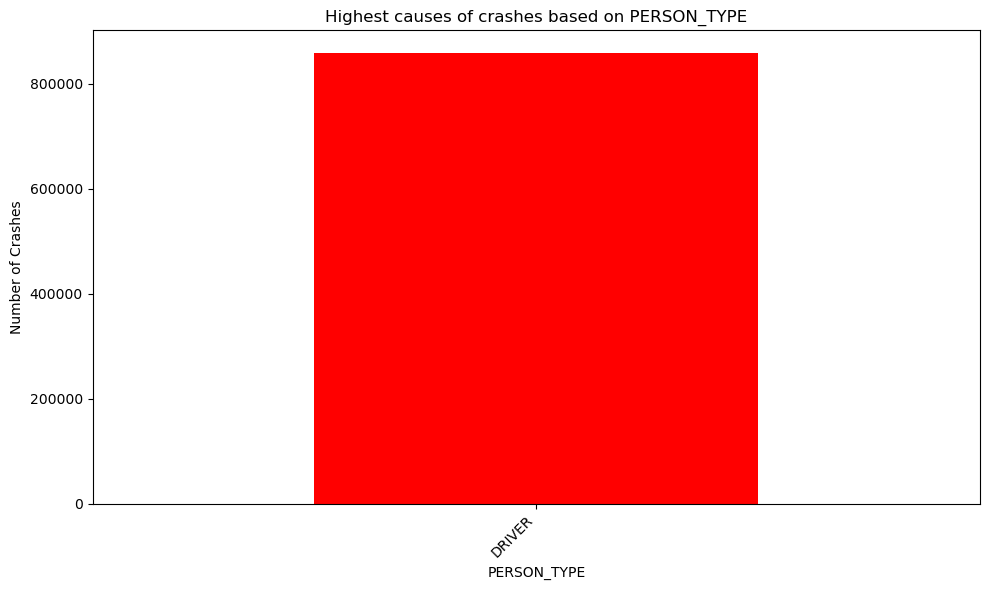

SEX is categorical with value counts:
SEX
M    516798
F    341029
X       723
Name: count, dtype: int64



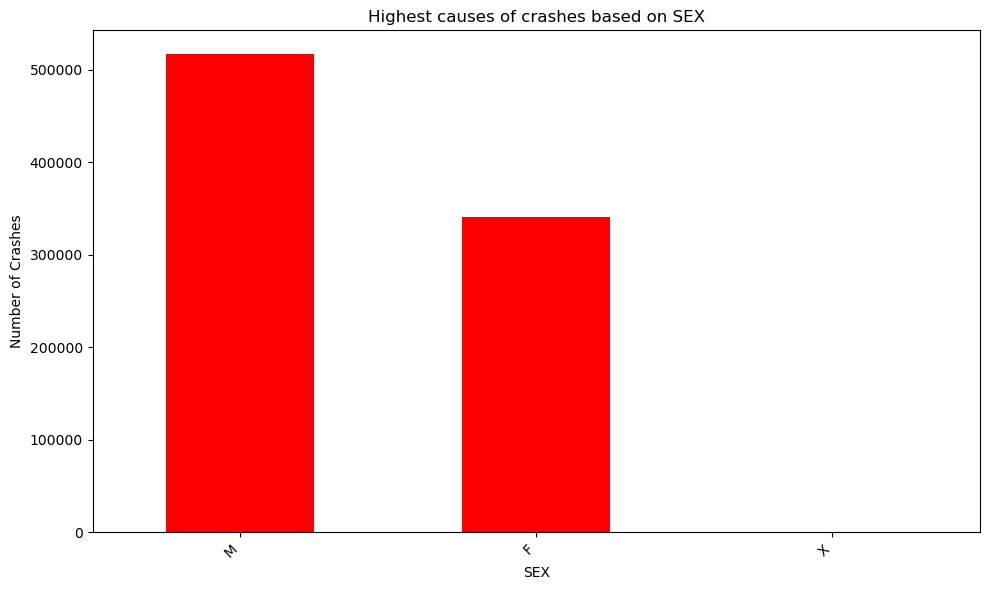

DRIVER_VISION is categorical with value counts:
DRIVER_VISION
NOT OBSCURED       461352
UNKNOWN            378365
OTHER                7283
MOVING VEHICLES      4751
PARKED VEHICLES      2920
Name: count, dtype: int64



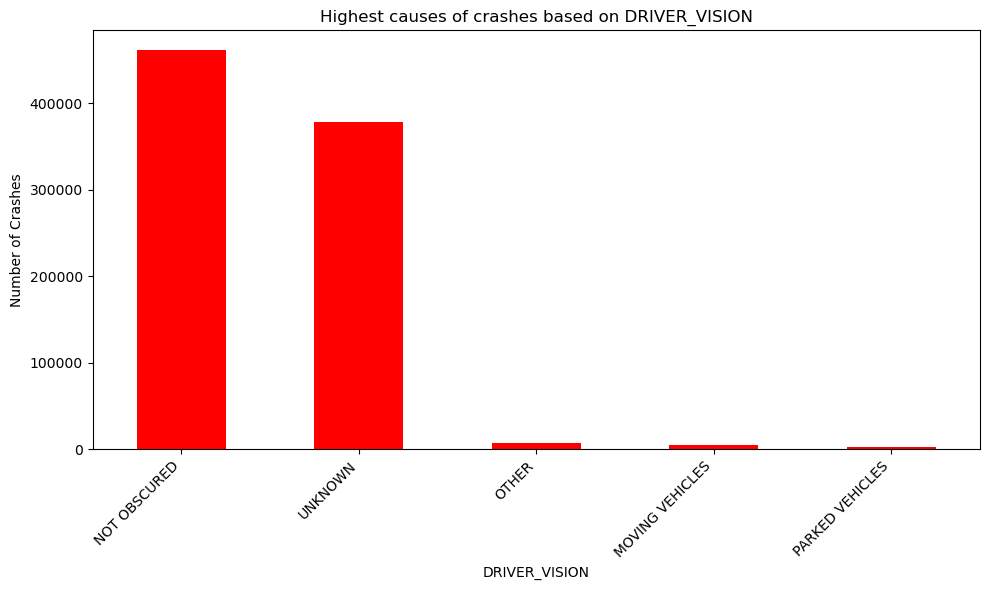

PHYSICAL_CONDITION is categorical with value counts:
PHYSICAL_CONDITION
NORMAL                669400
UNKNOWN               169238
EMOTIONAL               5429
IMPAIRED - ALCOHOL      4218
REMOVED BY EMS          2771
Name: count, dtype: int64



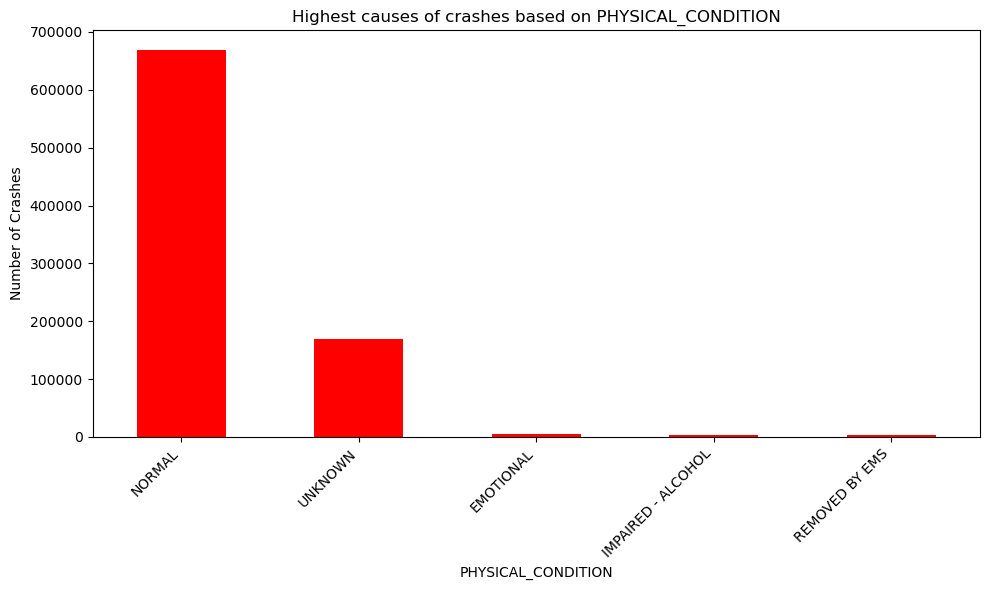

DRIVER_ACTION is categorical with value counts:
DRIVER_ACTION
NONE                    365242
UNKNOWN                 182539
OTHER                    88004
FAILED TO YIELD          73757
FOLLOWED TOO CLOSELY     41996
Name: count, dtype: int64



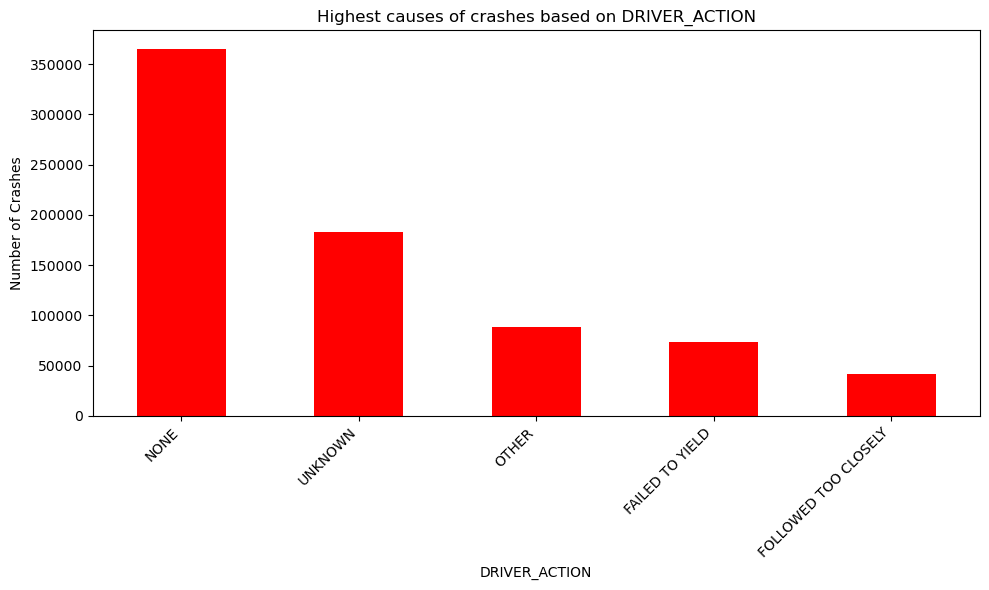

WEATHER_CONDITION is categorical with value counts:
WEATHER_CONDITION
CLEAR              679865
RAIN                71070
UNKNOWN             49129
CLOUDY/OVERCAST     26559
SNOW                23355
Name: count, dtype: int64



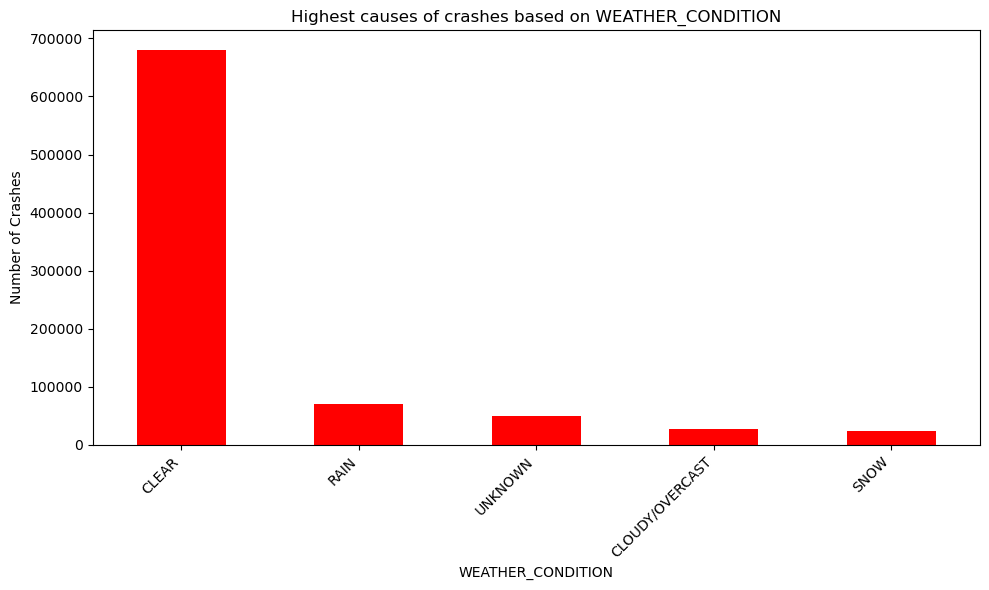

LIGHTING_CONDITION is categorical with value counts:
LIGHTING_CONDITION
DAYLIGHT                  584611
DARKNESS, LIGHTED ROAD    171213
UNKNOWN                    34822
DARKNESS                   30907
DUSK                       23364
Name: count, dtype: int64



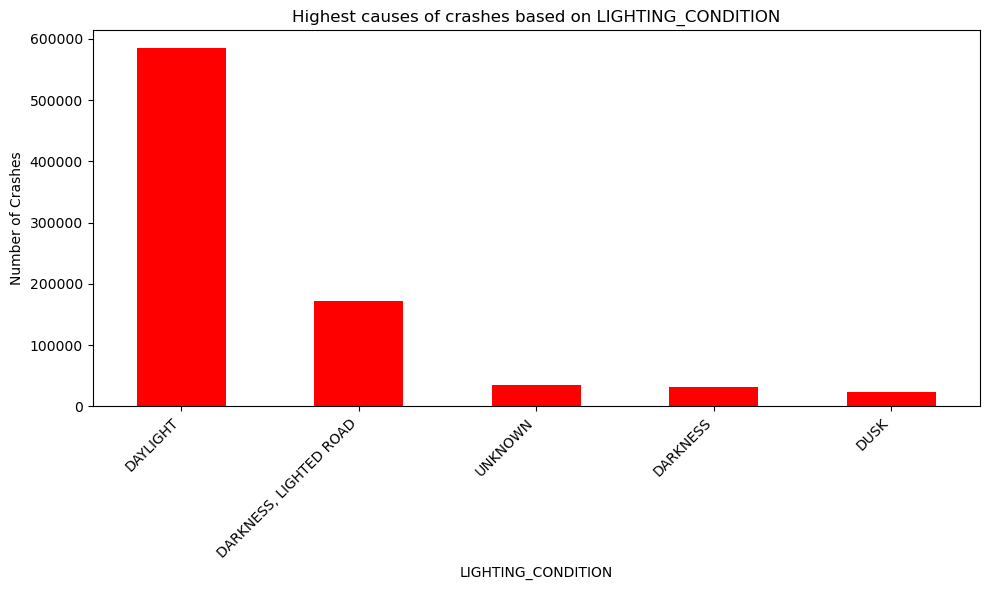

ROAD_DEFECT is categorical with value counts:
ROAD_DEFECT
NO DEFECTS      623923
UNKNOWN         224207
OTHER             3855
WORN SURFACE      3766
RUT, HOLES        1552
Name: count, dtype: int64



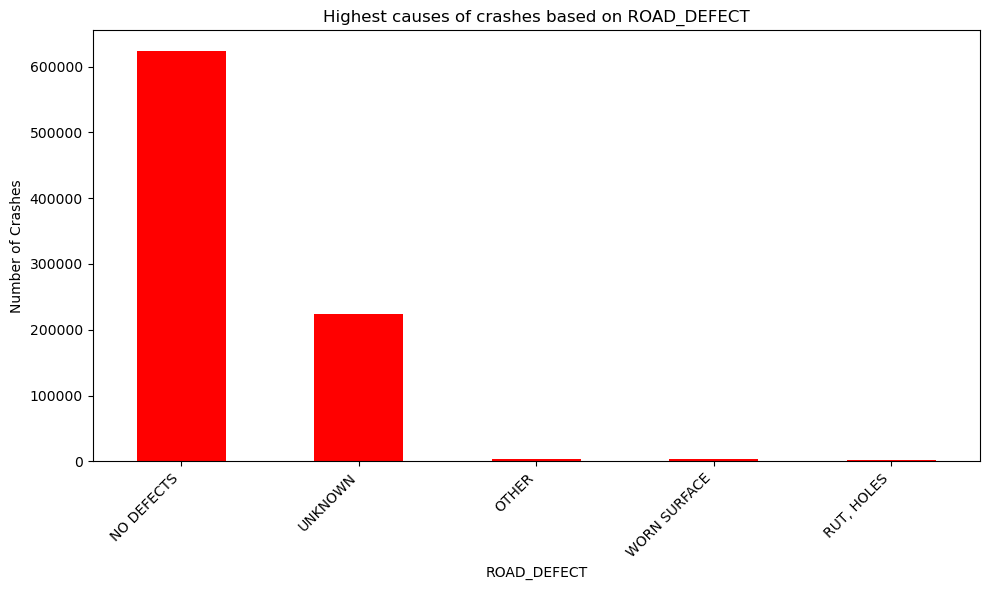

CRASH_TYPE is categorical with value counts:
CRASH_TYPE
NO INJURY / DRIVE AWAY              580012
INJURY AND / OR TOW DUE TO CRASH    278538
Name: count, dtype: int64



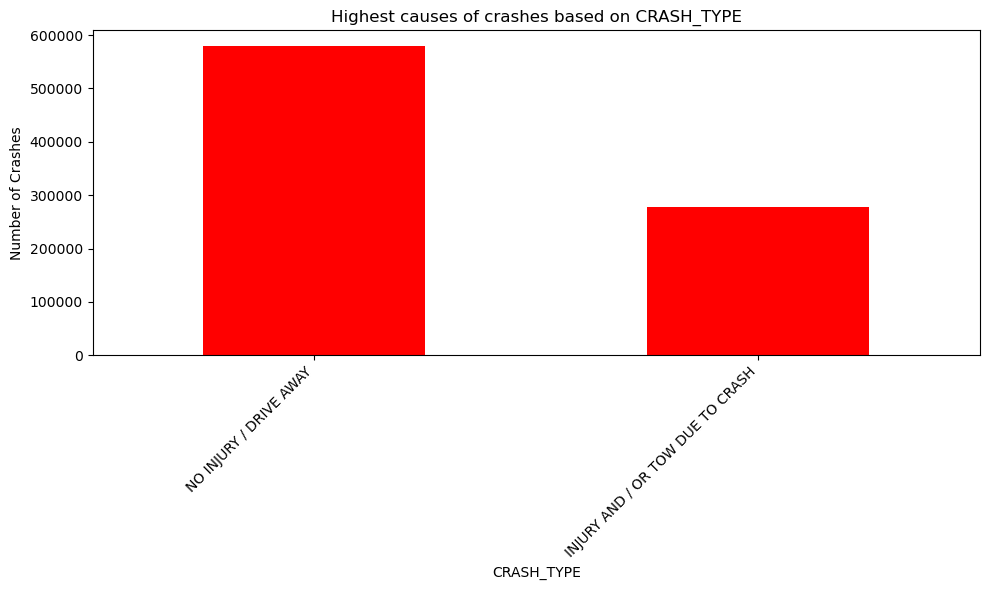

PRIM_CONTRIBUTORY_CAUSE is categorical with value counts:
PRIM_CONTRIBUTORY_CAUSE
UNABLE TO DETERMINE                       291352
FAILING TO YIELD RIGHT-OF-WAY             124226
FOLLOWING TOO CLOSELY                      98174
IMPROPER OVERTAKING/PASSING                50970
FAILING TO REDUCE SPEED TO AVOID CRASH     42900
Name: count, dtype: int64



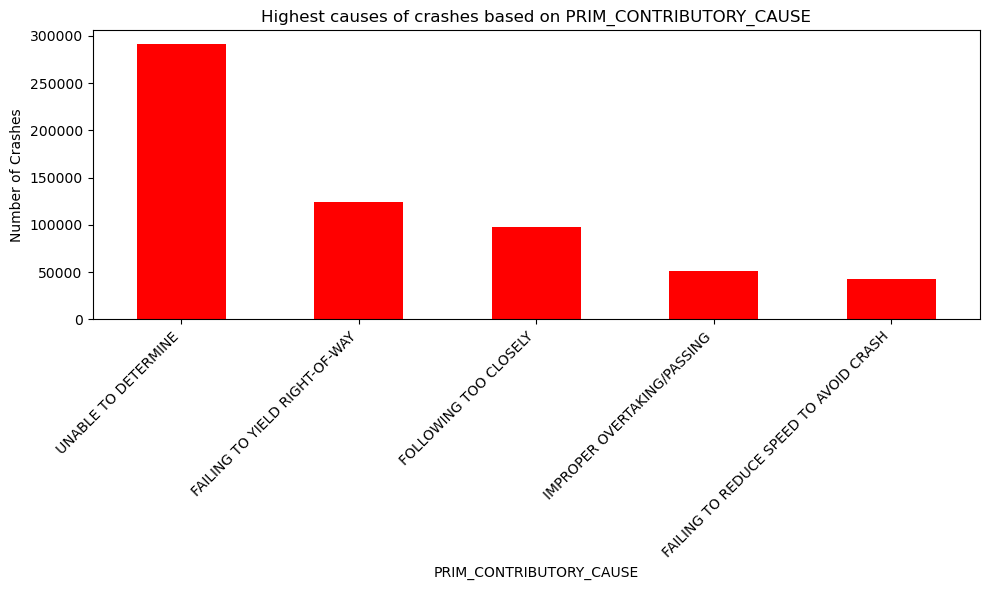

MAKE is categorical with value counts:
MAKE
TOYOTA       117635
CHEVROLET     95272
FORD          90249
HONDA         74679
NISSAN        66856
Name: count, dtype: int64



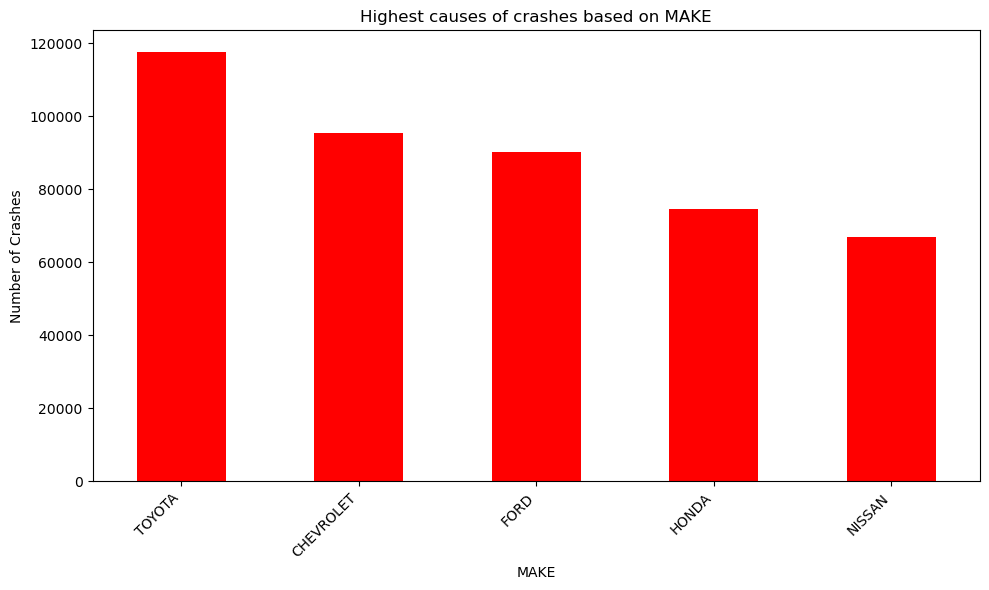

VEHICLE_USE is categorical with value counts:
VEHICLE_USE
PERSONAL      626883
UNKNOWN/NA    128992
OTHER          28364
NOT IN USE     17355
CTA             9736
Name: count, dtype: int64



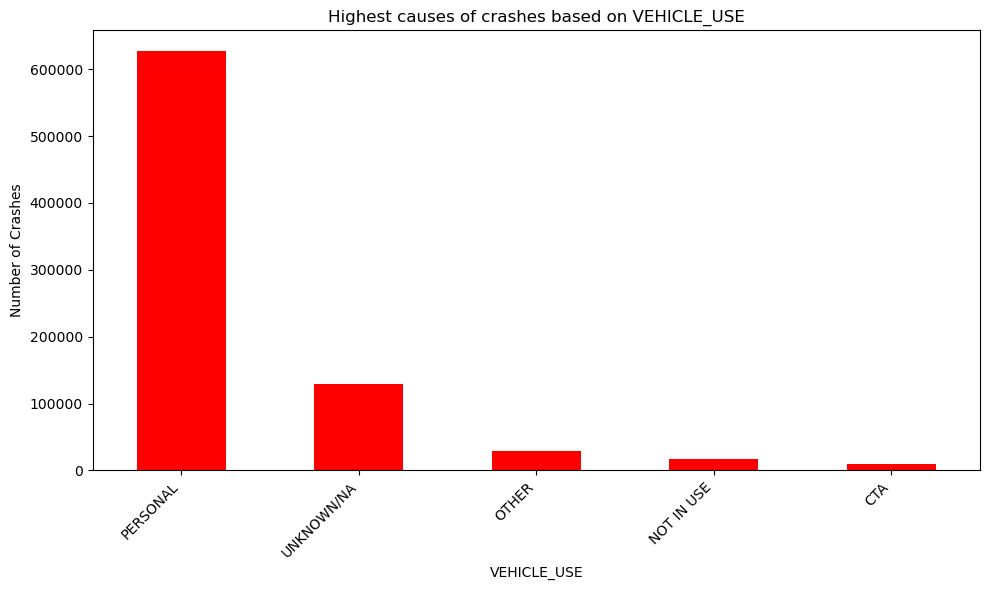

VEHICLE_DEFECT is categorical with value counts:
VEHICLE_DEFECT
NONE       424366
UNKNOWN    423479
OTHER        6841
BRAKES       2508
TIRES         379
Name: count, dtype: int64



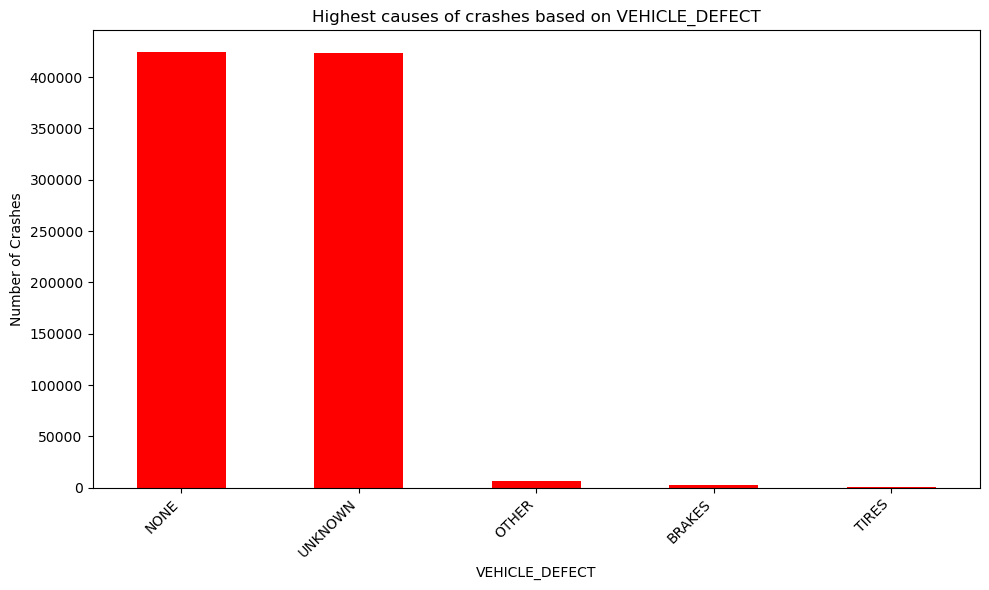

In [24]:
# Summarizing the impact of various categorical factors on accident occurence
for column in merged_df.columns:
    if pd.api.types.is_object_dtype(merged_df[column]):
        print(f"{column} is categorical with value counts:\n{merged_df[column].value_counts().head(5)}\n")
        # Plotting the categorical variables in a bar chart
        plt.figure(figsize=(10, 6))
        merged_df[column].value_counts().head(5).plot(kind='bar', color='red')
        plt.title(f'Highest causes of crashes based on {column}')
        plt.xlabel(column)
        plt.ylabel('Number of Crashes')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

Summary Findings on the influence of categorical factors on occurence of accidents.
Most accidents:

1. Occured when the weather was clear. However, when not clear, they occured in rainy conditions.
2. Occured in the daylight followed by darkly lighted roads.
3. Occured where roads had no defects followed by roads with worn out surfaces and potholes.
4. Did not involve any crash type injuries.
5. Did not have a primary cause but in those with a cause, the most common was either failing to give right of way or following too closely.
6. Involved Chevrolets, Fords and Nissans.
7. Involved personal cars.
8. Involved cars with no defects but of those which had brakes and tires had a defect.
9. Involved more men than women.
10. Were not caused by distractions, but of those were, the most common distractions were moving or parked vehicles.
11. Involved drivers with normal physical conditions, or drivers with impaired alcohol levels, emotionally unstable or fatigued.
12. Had no preceding driver action. Of those which had, drivers either failed to yield or followed too closely.  

In [25]:
# Summarizing the impact of various numerical factors on accident occurrence.
# We will do this by checking the value counts of each numerical factor on accident occurrence. Starting with age.
pd.cut(merged_df['AGE'], bins=10).value_counts()

AGE
(22.8, 33.7]     259792
(33.7, 44.6]     203605
(44.6, 55.5]     147259
(55.5, 66.4]     104247
(11.9, 22.8]      82895
(66.4, 77.3]      47329
(77.3, 88.2]      11599
(88.2, 99.1]        977
(0.891, 11.9]       814
(99.1, 110.0]        33
Name: count, dtype: int64

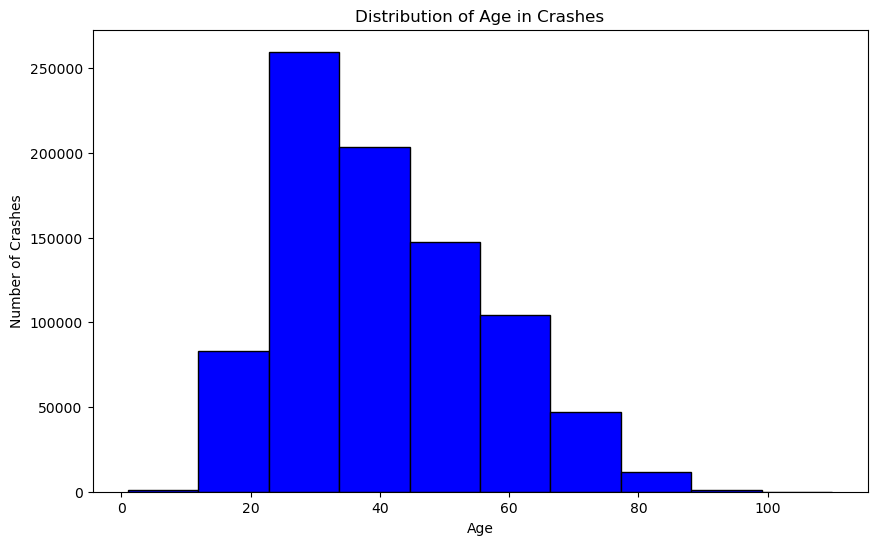

In [26]:
# Illustrating the distribution of age in a histogram
plt.figure(figsize=(10, 6))
plt.hist(merged_df['AGE'], bins=10, color='blue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Number of Crashes')
plt.title('Distribution of Age in Crashes')
plt.show()

In [27]:
# We will now check the distribution of crashes by hour of the day to see if there are any patterns in terms of time of day when crashes are more likely to occur.  
merged_df['CRASH_HOUR'].value_counts()

CRASH_HOUR
15    74142
16    71539
17    68384
14    59799
18    53414
13    52381
8     51447
12    49398
11    43523
7     40552
9     39707
10    38598
19    37980
20    29785
21    26000
22    22434
23    19569
6     17374
0     14840
1     12376
5     10119
2     10017
3      7844
4      7328
Name: count, dtype: int64

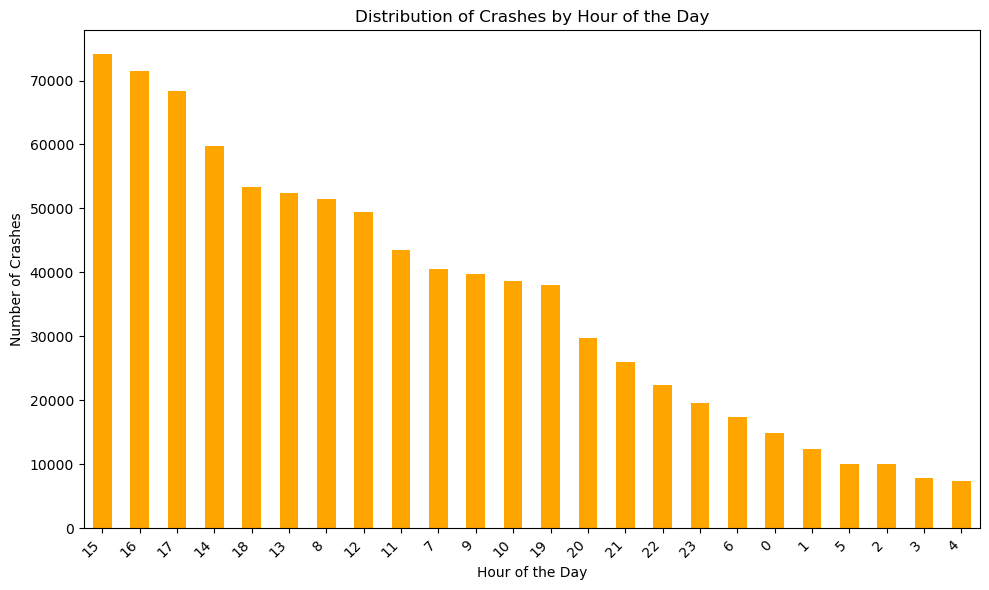

In [28]:
#illustrating the distribution of crashes by hour of the day in a bar chart
plt.figure(figsize=(10, 6))
merged_df['CRASH_HOUR'].value_counts().plot(kind='bar', color='orange')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Crashes')
plt.title('Distribution of Crashes by Hour of the Day')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [29]:
# We will now check the distribution of crashes by day of the week to see if there are any patterns in terms of day of the week when crashes are more likely to occur.
merged_df['CRASH_DAY_OF_WEEK'].value_counts()

CRASH_DAY_OF_WEEK
6    139953
5    128919
4    127634
3    125343
7    120724
2    115638
1    100339
Name: count, dtype: int64

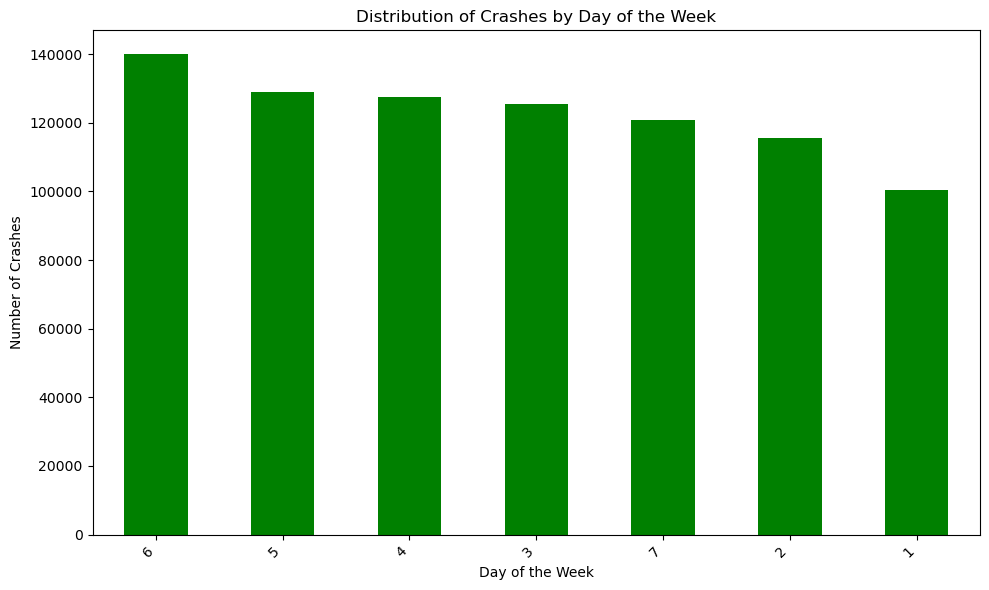

In [30]:
# illustrating the distribution of crashes by day of the week in a bar chart
plt.figure(figsize=(10, 6))
merged_df['CRASH_DAY_OF_WEEK'].value_counts().plot(kind='bar', color='green')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Crashes')
plt.title('Distribution of Crashes by Day of the Week')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [31]:
# We will now check the distribution of crashes by month to see if there are any patterns in terms of month when crashes are more likely to occur.
merged_df['CRASH_MONTH'].value_counts()

CRASH_MONTH
5     80877
8     77073
6     76508
10    74430
7     74165
9     73328
4     70227
3     69060
12    68835
1     67530
11    67020
2     59497
Name: count, dtype: int64

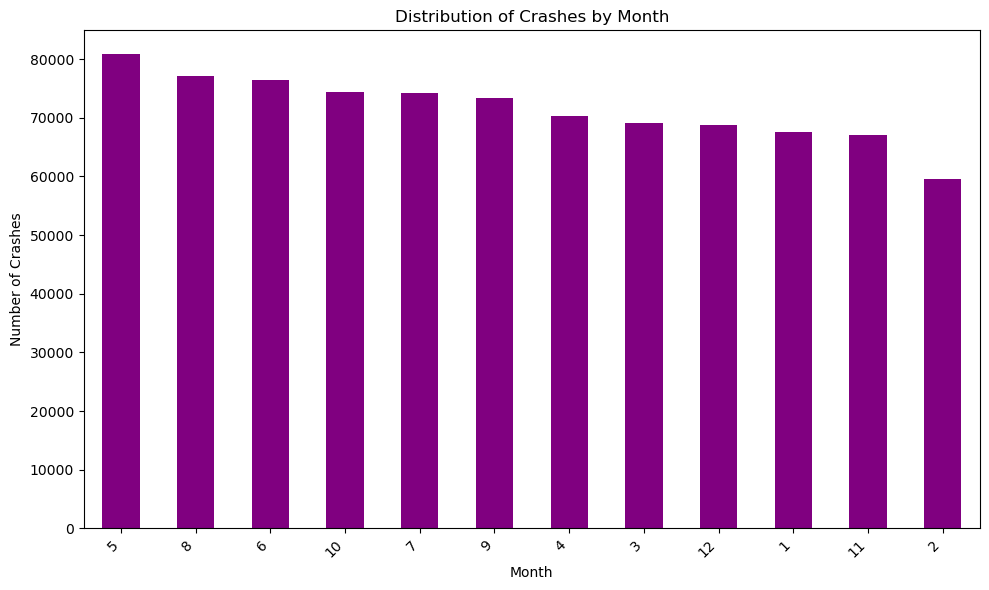

In [32]:
#illustrating the distribution of crashes by hour of the day in a bar chart
plt.figure(figsize=(10, 6))
merged_df['CRASH_MONTH'].value_counts().plot(kind='bar', color='purple')
plt.xlabel('Month')
plt.ylabel('Number of Crashes')
plt.title('Distribution of Crashes by Month')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Summary findings on the influence of numerical factors on the occurence of accidents.

Most accidents:

1. Involved drivers aged 20-40 years.
2. Occured between 3:00 p.m -5:00 p.m.
3. Occured on Fridays and Saturdays.
4. Occured in May and August.

# 5.7 Data Modeling